# U23AI035 - LAB 5 - RAI

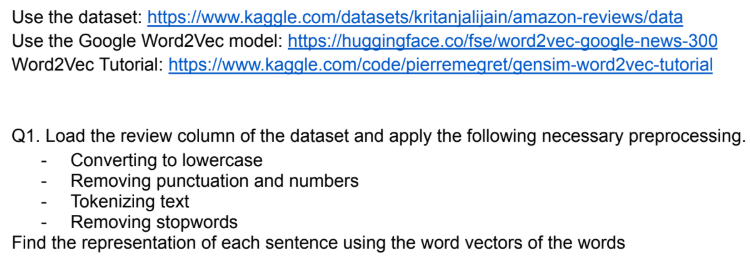

In [4]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import KeyedVectors
from tqdm import tqdm

In [5]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\JAIVAL
[nltk_data]     CHAUHAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\JAIVAL
[nltk_data]     CHAUHAN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [6]:
df = pd.read_csv("train.csv")

In [8]:
df.columns = ['polarity', 'title', 'text']

In [9]:
print(df.columns)

Index(['polarity', 'title', 'text'], dtype='object')


In [10]:
df = df[['polarity', 'text']]
df.dropna(inplace=True)

In [12]:
reviews = df['text'].dropna()

In [13]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    return tokens

In [14]:
processed_reviews = reviews.apply(preprocess_text)

In [15]:
print(processed_reviews.iloc[0])

['im', 'reading', 'lot', 'reviews', 'saying', 'best', 'game', 'soundtrack', 'figured', 'id', 'write', 'review', 'disagree', 'bit', 'opinino', 'yasunori', 'mitsudas', 'ultimate', 'masterpiece', 'music', 'timeless', 'im', 'listening', 'years', 'beauty', 'simply', 'refuses', 'fadethe', 'price', 'tag', 'pretty', 'staggering', 'must', 'say', 'going', 'buy', 'cd', 'much', 'money', 'one', 'feel', 'would', 'worth', 'every', 'penny']


In [19]:
word2vec_path = "word2vec-google-news-300.model"
w2v_model = KeyedVectors.load(word2vec_path)

In [20]:
print(w2v_model.vector_size)  

300


In [21]:
def sentence_vector(tokens, model, vector_size=300):
    vectors = []
    
    for word in tokens:
        if word in model:
            vectors.append(model[word])
    
    if len(vectors) == 0:
        return np.zeros(vector_size)
    
    return np.mean(vectors, axis=0)

In [23]:
sentence_vectors = []

for tokens in tqdm(processed_reviews):
    vec = sentence_vector(tokens, w2v_model)
    sentence_vectors.append(vec)

sentence_vectors = np.array(sentence_vectors)

100%|██████████| 3599999/3599999 [16:23<00:00, 3658.66it/s] 


In [24]:
print(sentence_vectors.shape)

(3599999, 300)


In [30]:
print("Sentence vector for first review:")
print(sentence_vectors[0])

Sentence vector for first review:
[ 0.06740887 -0.00212246  0.00781427  0.1231682  -0.05689109  0.05608163
  0.06535265 -0.08747678  0.09450029  0.07134824 -0.07580715 -0.12274356
 -0.02294406 -0.00259362 -0.08669523  0.09163089  0.06233327  0.11520348
  0.01331236 -0.09057692 -0.04471495  0.07151023  0.03751429 -0.01223085
  0.0143254  -0.00768671 -0.08063061  0.05842813 -0.01217596 -0.05098458
 -0.0675983   0.04845633 -0.06235411  0.03277886  0.01799793 -0.00577396
  0.03384065  0.01789112  0.0327132   0.06594129  0.07935835 -0.07699101
  0.1247767  -0.01245634 -0.04100669 -0.03546515  0.04278564  0.01793391
 -0.0242036  -0.02871853 -0.00607449  0.06650674 -0.00075416 -0.01793354
  0.02120804  0.04721144 -0.02309101 -0.07725614  0.06778178 -0.04719246
  0.02538393  0.08056008 -0.05741733 -0.06172292  0.01556545 -0.05582558
 -0.09479206  0.04147786 -0.03351221  0.05427663  0.06339022  0.04396854
  0.09888142  0.00276184 -0.15705872 -0.06189784  0.10710777  0.10203329
  0.05491526  0.0

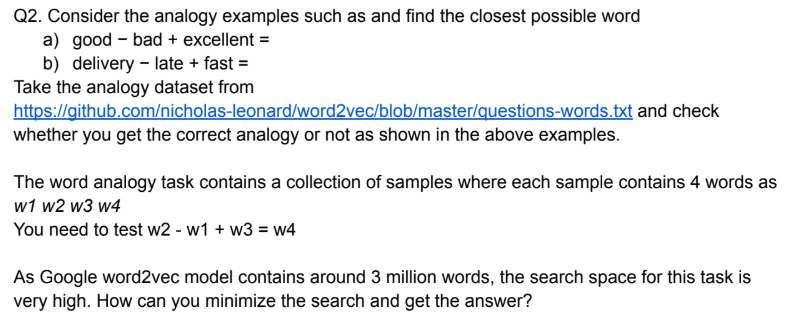

### 1. good - bad + excellent

In [31]:
result = w2v_model.most_similar(
    positive=['excellent', 'good'],
    negative=['bad'],
    topn=5
)

print(result)

[('terrific', 0.6986191868782043), ('superb', 0.6440027356147766), ('fantastic', 0.6409966945648193), ('great', 0.6319710612297058), ('exceptional', 0.5893021821975708)]


### 2. delivery - late + fast

In [32]:
result = w2v_model.most_similar(
    positive=['fast', 'delivery'],
    negative=['late'],
    topn=5
)

print(result)

[('delievery', 0.4610348641872406), ('twitch_muscles', 0.42857083678245544), ('Delivery', 0.4249102771282196), ('Eat##Hours.com', 0.3990197777748108), ('www.BobBruss.com', 0.39756283164024353)]


In [33]:
def load_analogies(file_path):
    analogies = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith(':'):
                continue
            words = line.strip().lower().split()
            if len(words) == 4:
                analogies.append(words)
    return analogies

In [34]:
analogies = load_analogies("questions-words.txt")

In [35]:
correct = 0
total = 0

for w1, w2, w3, w4 in analogies:
    if all(word in w2v_model for word in [w1, w2, w3]):
        try:
            predicted = w2v_model.most_similar(
                positive=[w2, w3],
                negative=[w1],
                topn=1
            )[0][0]

            total += 1
            if predicted == w4:
                correct += 1
        except KeyError:
            continue

accuracy = correct / total
print(f"Analogy Accuracy: {accuracy:.4f}")

Analogy Accuracy: 0.5483


## How to minimize the search?
### 1. Vocabulary Pruning (rare words, numbers, special tokens)
### 2. Top N-Nearest Neighbors only (search top n most similer words)
### 3. Normaize the vectors